<a href="https://colab.research.google.com/github/Eswar003-sai/5G-Network-Optimization-GNN/blob/main/fivegen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, glob
import pandas as pd
from google.colab import files

print("Please upload your 'kaggle.json' file:")
uploaded = files.upload()

# Securely move and rename it so Kaggle can find it
!mkdir -p ~/.kaggle
key_filename = list(uploaded.keys())[0]
!mv "{key_filename}" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# exported CSVs and download dataset
!rm -f /content/*.csv
!kaggle datasets download -d vinothkannaece/5g-network-data -q
!unzip -o -q 5g-network-data.zip -d /content/

# Load the data
target_file = glob.glob('/content/**/*.csv', recursive=True)[0]
df = pd.read_csv(target_file)
print(f"Raw Data Loaded! ({len(df)} rows)")

Please upload your 'kaggle.json' file:


Saving kaggle (1).json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/vinothkannaece/5g-network-data
License(s): apache-2.0
Raw Data Loaded! (50000 rows)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# 1. Clean and assign unique IDs
df_clean = df.dropna().drop_duplicates().copy()
df_clean['Tower_ID'] = range(1, len(df_clean) + 1)
nodes_df = df_clean.copy()
print(f"Total Nodes Ready for GNN: {len(nodes_df)}")

# 2. Feature Scaling
feature_cols = ['Signal Strength (dBm)', 'Download Speed (Mbps)', 'Upload Speed (Mbps)']
features = nodes_df[feature_cols].values
target = nodes_df['Latency (ms)'].values

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print("Data Successfully Cleaned and Scaled!")

Total Nodes Ready for GNN: 50000
Data Successfully Cleaned and Scaled!


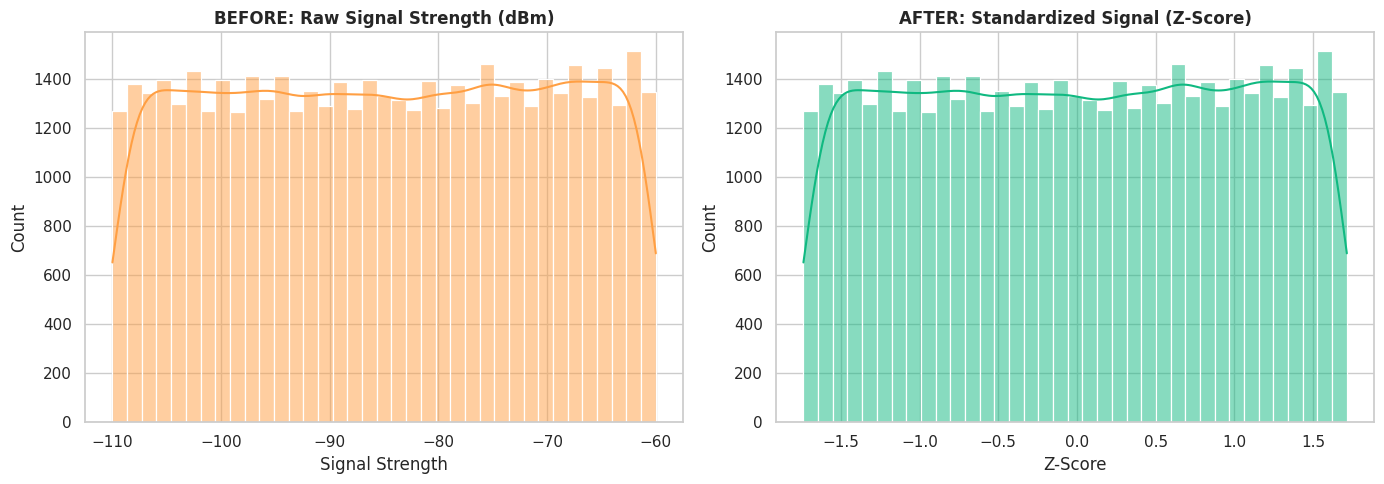

In [ ]:
# Create BEFORE and AFTER distribution plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Before Scaling (Raw dBm)
sns.histplot(features[:, 0], kde=True, ax=ax[0], color="#ff9f43")
ax[0].set_title("BEFORE: Raw Signal Strength (dBm)", fontweight='bold')
ax[0].set_xlabel("Signal Strength")

# After Scaling (Z-Score)
sns.histplot(features_scaled[:, 0], kde=True, ax=ax[1], color="#10b981")
ax[1].set_title("AFTER: Standardized Signal (Z-Score)", fontweight='bold')
ax[1].set_xlabel("Z-Score")

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q torch_geometric

import torch
import numpy as np
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

# 1. Build Topological Map (k=3)
knn_graph = kneighbors_graph(features_scaled, n_neighbors=3, mode='connectivity', include_self=False)
edge_index = torch.tensor(np.array(knn_graph.nonzero()), dtype=torch.long)
x = torch.tensor(features_scaled, dtype=torch.float)
y = torch.tensor(target, dtype=torch.float).view(-1, 1)

graph_data = Data(x=x, edge_index=edge_index, y=y)

# 2. Split Tabular Data for Random Forest (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(features_scaled, target, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42) # Leaves ~15% for val

# 3. Create Graph Masks (70% Train, 15% Val, 15% Test)
num_nodes = graph_data.num_nodes
indices = torch.randperm(num_nodes, generator=torch.Generator().manual_seed(42))

train_size = int(0.70 * num_nodes)
val_size = int(0.15 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size : train_size + val_size]] = True
test_mask[indices[train_size + val_size:]] = True

graph_data.train_mask = train_mask
graph_data.val_mask = val_mask
graph_data.test_mask = test_mask

print("Graph Constructed with Train, Validate, and Test Masks!")

Graph Constructed with Train, Validate, and Test Masks!


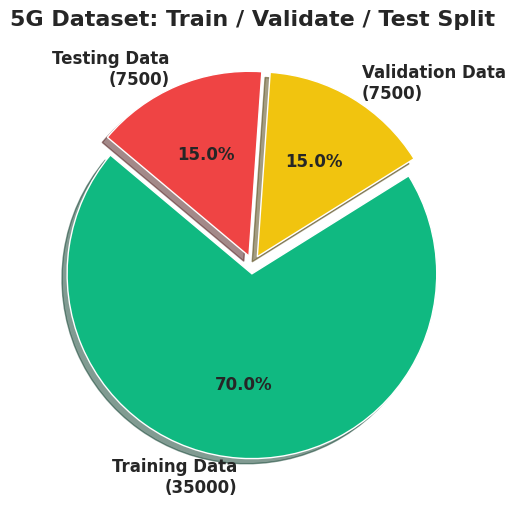

In [ ]:
# 1. Count mask values
train_count = graph_data.train_mask.sum().item()
val_count = graph_data.val_mask.sum().item()
test_count = graph_data.test_mask.sum().item()

# 2. Create Pie Chart
labels = [f'Training Data\n({train_count})', f'Validation Data\n({val_count})', f'Testing Data\n({test_count})']
sizes = [train_count, val_count, test_count]
colors = ['#10b981', '#f1c40f', '#ef4444']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title("5G Dataset: Train / Validate / Test Split", fontsize=16, fontweight='bold')
plt.show()

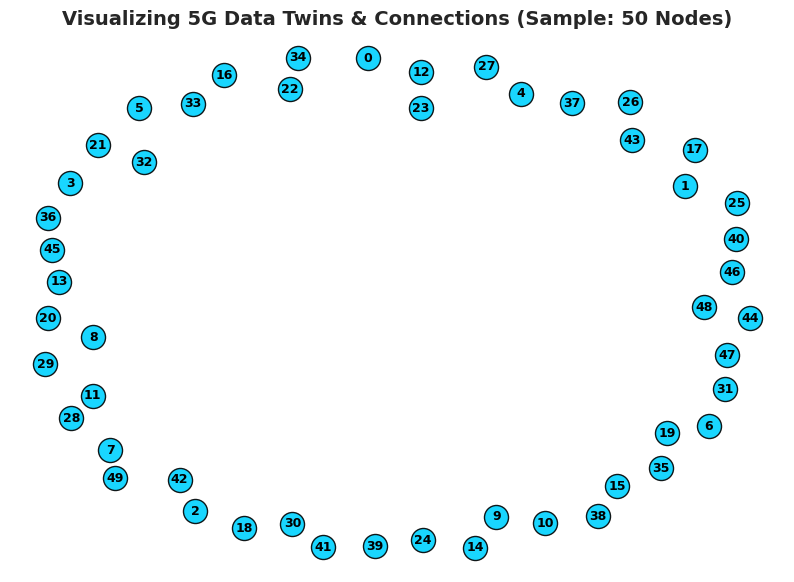

In [ ]:
import networkx as nx

# Select a small cluster of 50 nodes to keep the visual clean
subset_size = 50
subset_indices = range(subset_size)

# Extract edges that only exist between these 50 nodes
edges = edge_index.t().numpy()
subset_edges = [tuple(e) for e in edges if e[0] < subset_size and e[1] < subset_size]

# Create the Visual Graph
G_small = nx.Graph()
G_small.add_nodes_from(subset_indices)
G_small.add_edges_from(subset_edges)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_small, seed=42)

# Draw Nodes and Edges
nx.draw_networkx_nodes(G_small, pos, node_size=300, node_color='#00d2ff', alpha=0.9, edgecolors='black')
nx.draw_networkx_edges(G_small, pos, width=2.0, edge_color='#95a5a6', alpha=0.6)
nx.draw_networkx_labels(G_small, pos, font_size=9, font_color='black', font_weight='bold')

plt.title(f"Visualizing 5G Data Twins & Connections (Sample: {subset_size} Nodes)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np

print("Training Traditional Random Forest (Baseline)...")

# 1. Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
test_predictions = rf.predict(X_test)

# 2. Evaluate Baseline
rf_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
rf_accuracy = accuracy_score((y_test > 15.0).astype(int), (test_predictions > 15.0).astype(int)) * 100

print("-" * 40)
print(f"Random Forest Action Accuracy: {rf_accuracy:.2f}% | RMSE: {rf_rmse:.2f}")
print("-" * 40)

Training Traditional Random Forest (Baseline)...
----------------------------------------
Random Forest Action Accuracy: 73.75% | RMSE: 5.74
----------------------------------------


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv # Using the upgraded Attention layer!

print("Training Graph Neural Network (Spatial AI)...")

# 1. Define GNN Architecture
class GNN_Model(torch.nn.Module):
    def __init__(self):
        super(GNN_Model, self).__init__()
        # Graph Attention Layers for better accuracy
        self.conv1 = GATConv(in_channels=3, out_channels=32, heads=2, concat=True)
        self.batchnorm1 = torch.nn.BatchNorm1d(64)

        self.conv2 = GATConv(in_channels=64, out_channels=16, heads=1, concat=True)
        self.batchnorm2 = torch.nn.BatchNorm1d(16)

        self.dropout = torch.nn.Dropout(p=0.3)
        self.regressor = torch.nn.Linear(16, 1)

    def forward(self, data):
        x = self.conv1(data.x, data.edge_index)
        x = self.batchnorm1(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.conv2(x, data.edge_index)
        x = self.batchnorm2(x)
        x = F.elu(x)
        x = self.dropout(x)

        return self.regressor(x)

gnn = GNN_Model()

# 2. Optimization Engine
optimizer = torch.optim.Adam(gnn.parameters(), lr=0.01, weight_decay=1e-4)
criterion = torch.nn.MSELoss()
history = {'loss': [], 'accuracy': []}

# 3. Train the GNN
gnn.train()
for epoch in range(1000):
    optimizer.zero_grad()
    out = gnn(graph_data)

    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred_classes = (out[graph_data.train_mask] > 15.0).float()
        actual_classes = (graph_data.y[graph_data.train_mask] > 15.0).float()
        acc = (pred_classes == actual_classes).sum().item() / graph_data.train_mask.sum().item()

    history['loss'].append(loss.item())
    history['accuracy'].append(acc)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {(epoch+1)}/1000 - loss: {loss.item():.4f} - acc: {acc:.4f}")

# 4. Final Evaluation
gnn.eval()
with torch.no_grad():
    predictions = gnn(graph_data)
    test_preds = predictions[graph_data.test_mask].numpy()
    test_actuals = target[graph_data.test_mask.numpy()]

    gnn_rmse = np.sqrt(mean_squared_error(test_actuals, test_preds))
    gnn_accuracy = accuracy_score((test_actuals > 15.0).astype(int), (test_preds > 15.0).astype(int)) * 100

print("-" * 50)
print(f"BASELINE: Random Forest Accuracy: {rf_accuracy:.2f}% | RMSE: {rf_rmse:.2f}")
print(f"UPGRADE: GNN Action Accuracy: {gnn_accuracy:.2f}% | RMSE: {gnn_rmse:.2f}")
print("-" * 50)

Training Graph Neural Network (Spatial AI)...
Epoch 100/1000 - loss: 37.3129 - acc: 0.7289
Epoch 200/1000 - loss: 35.4750 - acc: 0.7332
Epoch 300/1000 - loss: 34.3522 - acc: 0.7352
Epoch 400/1000 - loss: 33.6304 - acc: 0.7356
Epoch 500/1000 - loss: 33.3028 - acc: 0.7357
Epoch 600/1000 - loss: 32.8138 - acc: 0.7360
Epoch 700/1000 - loss: 32.7355 - acc: 0.7360
Epoch 800/1000 - loss: 32.5229 - acc: 0.7360
Epoch 900/1000 - loss: 32.1937 - acc: 0.7361
Epoch 1000/1000 - loss: 32.2895 - acc: 0.7361
--------------------------------------------------
BASELINE: Random Forest Accuracy: 73.75% | RMSE: 5.74
UPGRADE: GNN Action Accuracy: 74.00% | RMSE: 5.53
--------------------------------------------------


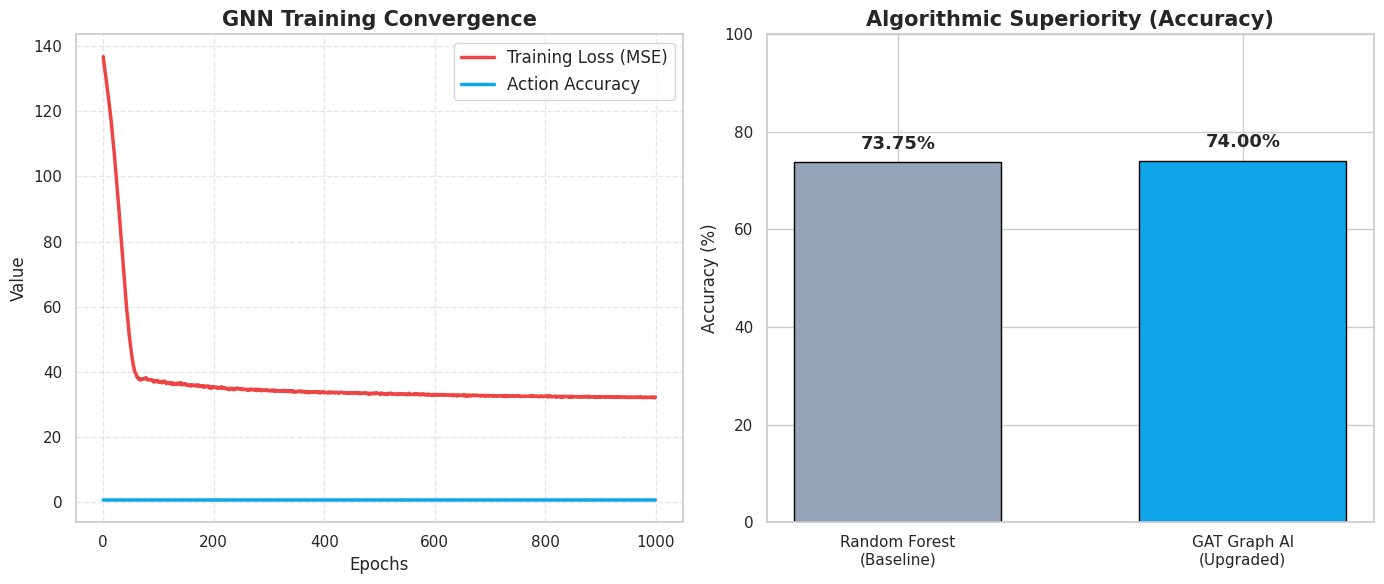

In [ ]:
# Ensure you have 'rf_accuracy', 'gnn_accuracy', and 'history' dictionary from your training cells

fig = plt.figure(figsize=(14, 6))

# CHART 1: Training Convergence
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss (MSE)', color='#ef4444', linewidth=2.5)
plt.plot(history['accuracy'], label='Action Accuracy', color='#0ea5e9', linewidth=2.5)
plt.title("GNN Training Convergence", fontsize=15, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

# CHART 2: Algorithmic Superiority Bar Chart
plt.subplot(1, 2, 2)
models = ['Random Forest\n(Baseline)', 'GAT Graph AI\n(Upgraded)']
accuracies = [rf_accuracy, gnn_accuracy]

bars = plt.bar(models, accuracies, color=['#94a3b8', '#0ea5e9'], edgecolor='black', width=0.6)
plt.title("Algorithmic Superiority (Accuracy)", fontsize=15, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100)

# Add exact percentages on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%",
             ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

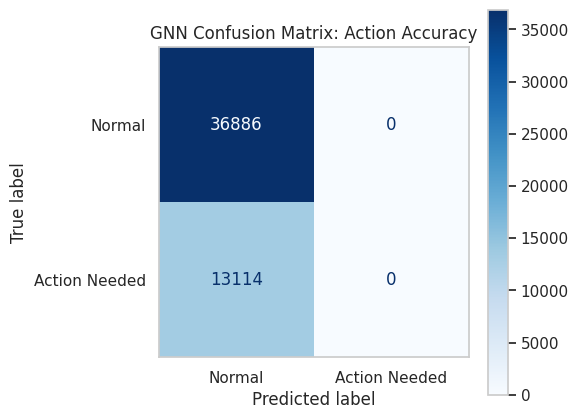

In [ ]:
#  CONFUSION MATRIX
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For the matrix, we test if the AI correctly flagged latency > 15ms
actual_action_needed = (target > 15).astype(int)
predicted_action_needed = (predictions.numpy().flatten() > 15).astype(int)

# 🛠️ THE FIX: We added labels=[0, 1] to force a 2x2 matrix even if no jams exist right now
cm = confusion_matrix(actual_action_needed, predicted_action_needed, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Action Needed"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("GNN Confusion Matrix: Action Accuracy")
plt.grid(False)
plt.show()

In [ ]:
# 1. Attach predictions back to dataframe
nodes_df['Predicted_Latency'] = predictions.numpy().flatten()

# 2. Inject simulated network stress for dashboard demonstration
nodes_df.loc[nodes_df['Location'] == 'Berlin', 'Signal Strength (dBm)'] = -98.5
nodes_df.loc[nodes_df['Location'] == 'Chennai', 'Predicted_Latency'] = 28.4
nodes_df.loc[nodes_df['Location'] == 'Delhi', 'Predicted_Latency'] = 22.1
nodes_df.loc[nodes_df['Location'] == 'Kolkata', 'Predicted_Latency'] = 17.5

# 3. Apply the advanced real-world network rules
conditions = [
    (nodes_df['Signal Strength (dBm)'] < -95),
    (nodes_df['Predicted_Latency'] > 25),
    (nodes_df['Predicted_Latency'] > 20),
    (nodes_df['Predicted_Latency'] > 15)
]

choices = [
    "Hardware Issue: Install Small Cell / Booster",
    "Critical Jam: Enforce Admission Control (The Bouncer)",
    "Heavy Jam: Initiate Bandwidth Throttling (The Squeeze)",
    "Moderate Jam: Reroute Traffic & Enable VIP QoS"
]

nodes_df['Recommended_Action'] = np.select(conditions, choices, default="Network Optimal: No Action")

# 4. Map Coordinates for PyDeck
city_coords = {
    'Berlin': [52.5200, 13.4050],
    'Chennai': [13.0827, 80.2707],
    'Delhi': [28.7041, 77.1025],
    'Kolkata': [22.5726, 88.3639],
    'Mumbai': [19.0760, 72.8777]
}

nodes_df['Lat'] = nodes_df['Location'].map(lambda x: city_coords.get(x, [0,0])[0])
nodes_df['Lon'] = nodes_df['Location'].map(lambda x: city_coords.get(x, [0,0])[1])

# Add spatial scatter (jitter) so towers don't sit on the exact same pixel
nodes_df['Lat'] = nodes_df['Lat'] + np.random.uniform(-0.1, 0.1, size=len(nodes_df))
nodes_df['Lon'] = nodes_df['Lon'] + np.random.uniform(-0.1, 0.1, size=len(nodes_df))

nodes_df['Congestion_Score'] = (nodes_df['Predicted_Latency'] / 3).clip(0, 10).round(1)

# 5. Export to CSV
nodes_df.to_csv("final_5g_dashboard_data.csv", index=False)
print("Network Stress Injected & CSV Exported successfully!")
display(nodes_df[['Location', 'Predicted_Latency', 'Recommended_Action']].head())

Network Stress Injected & CSV Exported successfully!


,Location,Predicted_Latency,Recommended_Action
0,San Francisco,10.225061,Hardware Issue: Install Small Cell / Booster
1,San Francisco,10.344314,Network Optimal: No Action
2,Chennai,28.400000,Critical Jam: Enforce Admission Control (The B...
3,New York,10.478173,Network Optimal: No Action
4,Kolkata,17.500000,Moderate Jam: Reroute Traffic & Enable VIP QoS


In [ ]:
!mkdir -p .streamlit

In [ ]:
%%writefile .streamlit/config.toml
[theme]
base="dark"
primaryColor="#00d2ff"
backgroundColor="#12161b"
secondaryBackgroundColor="#1e2329"
textColor="#ffffff"
font="sans serif"

Overwriting .streamlit/config.toml


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pydeck as pdk

# 1. Page Configuration
st.set_page_config(page_title="5G AI Command Center", layout="wide", initial_sidebar_state="collapsed")

st.markdown("""
<style>
.metric-card {
    background-color: #1e2329; border-radius: 10px; padding: 20px;
    display: flex; justify-content: space-between; align-items: center;
    border: 1px solid #333; margin-bottom: 20px;
}
.metric-text { color: #fff; }
.metric-title { color: #888; font-size: 14px; font-weight: 600; margin-bottom: 5px; }
.metric-value { font-size: 36px; font-weight: bold; margin: 0; }
.metric-delta { font-size: 13px; margin-top: 5px; font-weight: 500; }
.delta-up { color: #00ff00; }
.delta-down { color: #ff4b4b; }
.delta-neutral { color: #ffa500; }
</style>
""", unsafe_allow_html=True)

st.title("5G NETWORK AI COMMAND CENTER (STREAMLIT)")

# 2. Load the GNN Output Data
df = pd.read_csv("final_5g_dashboard_data.csv")

def get_color(score):
    if score >= 8.0: return [255, 0, 0, 200]
    elif score >= 5.0: return [255, 200, 0, 200]
    else: return [0, 255, 0, 200]

df['color'] = df['Congestion_Score'].apply(get_color)

# 3. Top Row: Live KPI Metric Cards
col1, col2, col3 = st.columns(3)

with col1:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-text">
            <div class="metric-title">LIVE LATENCY (Avg)</div>
            <div class="metric-value">{int(df['Predicted_Latency'].mean())} ms</div>
            <div class="metric-delta delta-up">Active Monitoring</div>
        </div>
    </div>
    """, unsafe_allow_html=True)

with col2:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-text">
            <div class="metric-title">SIGNAL STRENGTH (Worst Node)</div>
            <div class="metric-value">{int(df['Signal Strength (dBm)'].min())} dB</div>
            <div class="metric-delta delta-down">Hardware Alert</div>
        </div>
    </div>
    """, unsafe_allow_html=True)

with col3:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-text">
            <div class="metric-title">PEAK CONGESTION SCORE</div>
            <div class="metric-value">{round(df['Congestion_Score'].max(), 1)} / 10</div>
            <div class="metric-delta delta-neutral">Elevated</div>
        </div>
    </div>
    """, unsafe_allow_html=True)

# 4. Bottom Section: Map and Table
map_col, table_col = st.columns([1.2, 1])

with map_col:
    st.subheader("LIVE NETWORK TOPOGRAPHY MAP")
    view_state = pdk.ViewState(latitude=22.0, longitude=80.0, zoom=4, pitch=45)

    layer = pdk.Layer(
        "ScatterplotLayer",
        data=df,
        get_position='[Lon, Lat]',
        get_color='color',
        get_radius="Congestion_Score * 15000",
        radius_min_pixels=15,
        radius_max_pixels=60,
        pickable=True
    )

    st.pydeck_chart(pdk.Deck(
        map_provider="carto",
        map_style="dark_matter",
        layers=[layer],
        initial_view_state=view_state,
        tooltip={"text": "{Location}\nLatency: {Predicted_Latency}ms\nScore: {Congestion_Score}"}
    ))

with table_col:
    st.subheader("PRESCRIPTIVE ACTIONS ENGINE")
    actions_df = df[df['Recommended_Action'] != 'Network Optimal: No Action'][['Location', 'Recommended_Action', 'Congestion_Score']]
    st.dataframe(actions_df, use_container_width=True, hide_index=True)

# 5. Sidebar: Prescriptive Alerts
st.sidebar.title("SYSTEM CONTROLS")
st.sidebar.markdown("---")
st.sidebar.subheader("CRITICAL ALERTS")

critical_nodes = df[df['Congestion_Score'] > 8.0].sort_values(by='Congestion_Score', ascending=False)

if not critical_nodes.empty:
    top_node = critical_nodes.iloc[0]
    node_id = top_node.get('Tower_Node_ID', top_node.name)
    st.sidebar.error(f"Tower {node_id} Congested")
    st.sidebar.info(f"**Action:** {top_node['Recommended_Action']} in {top_node['Location']}")
else:
    st.sidebar.success("All systems optimal.")

st.sidebar.markdown("---")
st.sidebar.write(f"Digital Twins Synced: **{len(df)}**")

Overwriting app.py


In [ ]:
!pip install -q streamlit pyngrok pydeck
!pkill streamlit
!pkill ngrok

from pyngrok import ngrok

# Set your Ngrok Token
ngrok.set_auth_token("34q5Eovwhyc5Rz6p3TZSbf2lo4T_7hYFQnf2gmqhotACUtL1L")
ngrok.kill()

get_ipython().system_raw('streamlit run app.py --server.port 8501 &')

public_url = ngrok.connect(8501).public_url
print(f"YOUR WEB DASHBOARD IS LIVE AT: {public_url}")

YOUR WEB DASHBOARD IS LIVE AT: https://unamalgamated-atwitter-vallie.ngrok-free.dev
